# Multi-Scale Regression: Predict y from X, c, and tau

This notebook builds a toy pipeline to test three decoding strategies:
- Direct regression
- Sign + exponent + fraction regression
- IEEE754 bit prediction

We will keep the data tiny and synthetic, but keep the input format consistent with the proposal.

In [1]:
import math
import random
from dataclasses import dataclass
from typing import Callable
import numpy as np
import torch
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import simplipy
from simplipy import SimpliPyEngine

from flash_ansr.expressions.compilation import codify, safe_f
from flash_ansr.expressions.token_ops import identify_constants

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def log_space_smoothing(x, y, sigma=2, num_points=1000):
    """
    Smooths the curve defined by (x, y) using a Gaussian filter in log-space.
    
    Parameters
    ----------
    x : array-like
        The x-coordinates of the data points.
    y : array-like
        The y-coordinates of the data points.
    sigma : float, optional
        The standard deviation for Gaussian kernel, by default 2.
    num_points : int, optional
        The number of points in the log-space grid, by default 1000.

    Returns
    -------
    x_smooth : np.ndarray
        The x-coordinates of the smoothed curve.
    y_smooth : np.ndarray
        The y-coordinates of the smoothed curve.
    """
    if isinstance(x, torch.Tensor): x = x.cpu().numpy()
    if isinstance(y, torch.Tensor): y = y.cpu().numpy()

    # 1. Define a regular grid in log space
    x_log = np.log(x)
    x_grid_log = np.linspace(x_log.min(), x_log.max(), num_points)

    # 2. Interpolate y onto this log-grid
    # This effectively handles the "varying density" of original points
    y_grid = np.interp(x_grid_log, x_log, y)

    # 3. Apply smoothing (fixed window in log-space = growing window in linear-space)
    y_smooth = gaussian_filter1d(y_grid, sigma=sigma)

    # Transform x grid back to linear space for plotting
    x_smooth = np.exp(x_grid_log)

    return x_smooth, y_smooth

In [3]:
def float32_to_bits(value: float) -> np.ndarray:
    value = np.array([value], dtype=np.float32)
    as_int = value.view(np.uint32)[0]
    shifts = np.arange(31, -1, -1, dtype=np.uint32)
    bits = ((as_int >> shifts) & 1).astype(np.float32)
    return bits

def bits_to_float32(bits: np.ndarray) -> float:
    bits = np.asarray(bits, dtype=np.uint8).reshape(32)
    shifts = np.arange(31, -1, -1, dtype=np.uint32)
    as_int = np.sum(bits.astype(np.uint32) << shifts, dtype=np.uint32)
    value = np.array([as_int], dtype=np.uint32).view(np.float32)[0]
    return float(value)

def torch_float32_to_bits(x: torch.Tensor) -> torch.Tensor:
    x = x.to(torch.float32)
    i = x.view(torch.int32)
    bit_idx = torch.arange(31, -1, -1, device=x.device, dtype=torch.int32)
    bits = ((i.unsqueeze(-1) >> bit_idx) & 1).to(torch.float32)
    return bits

def encode_float32_matrix(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float32)
    flat = values.reshape(-1)
    bit_rows = np.stack([float32_to_bits(v) for v in flat], axis=0)
    return bit_rows.reshape(values.shape + (32,))

In [ ]:
simplipy_engine = SimpliPyEngine.load("dev_7-3")

toy_infix_expressions = [
    "x1 + x2",
    "x1 * x2",
    # "x1 * x1 + x2",
    # "x1 + 2 * x2",
    # "x1 * x2 + 1",
    # "x1 - x2",
    # "x1 / (x2 + 1)",
    # "x1 * x1 - x2 * x2",
    # "x1 + x2 + 3",
    # "x1 * (x2 + 2)",
]

def to_prefix(expr: str) -> list[str]:
    if simplipy_engine is None:
        raise RuntimeError("SimpliPyEngine is not available.")
    prefix = simplipy_engine.parse(expr, mask_numbers=True)
    return prefix

def compile_prefix(prefix: list[str], variables: list[str]) -> tuple[Callable, list[str]]:
    prefix_real = simplipy_engine.operators_to_realizations(prefix)
    prefix_const, constants = identify_constants(prefix_real)
    code_string = simplipy_engine.prefix_to_infix(prefix_const, realization=True)
    code = codify(code_string, variables + constants)
    eval_ctx = {"np": np, "numpy": np, "math": math}
    eval_ctx["simplipy"] = simplipy
    f = eval(code, eval_ctx)
    return f, constants

if simplipy_engine is not None:
    toy_prefix_expressions = [to_prefix(expr) for expr in toy_infix_expressions]
else:
    toy_prefix_expressions = [
        ["+", "x1", "x2"],
        ["*", "x1", "x2"],
        # ["+", "*", "x1", "x1", "x2"],
        # ["+", "x1", "*", "<constant>", "x2"],
        # ["+", "*", "x1", "x2", "<constant>"],
        # ["-", "x1", "x2"],
        # ["/", "x1", "+", "x2", "<constant>"],
        # ["-", "*", "x1", "x1", "*", "x2", "x2"],
        # ["+", "+", "x1", "x2", "<constant>"],
        # ["*", "x1", "+", "x2", "<constant>"]
    ]

In [5]:
SPECIAL_TOKENS = ["<pad>", "<bos>", "<expression>", "</expression>", "<pred_y>"]
VARIABLES = ["x1", "x2"]

def build_vocab(prefix_expressions: list[list[str]]) -> dict[str, int]:
    tokens = set(SPECIAL_TOKENS)
    for expr in prefix_expressions:
        tokens.update(expr)
    tokens.update(VARIABLES)
    tokens.update(["C_0", "C_1", "C_2", "C_3"])
    return {tok: i for i, tok in enumerate(sorted(tokens))}

vocab = build_vocab(toy_prefix_expressions)
ivocab = {i: t for t, i in vocab.items()}

def tokenize_expression(prefix: list[str]) -> list[str]:
    return ["<bos>", "<expression>"] + prefix + ["</expression>", "<pred_y>"]

def make_numeric_overlay(tokens: list[str], x: np.ndarray, constants: list[float]) -> np.ndarray:
    overlay = np.zeros((len(tokens), 32), dtype=np.float32)
    for i, tok in enumerate(tokens):
        if tok in VARIABLES:
            idx = VARIABLES.index(tok)
            overlay[i] = float32_to_bits(float(x[idx]))
        elif tok.startswith("C_"):
            c_idx = int(tok.split("_")[1])
            if c_idx < len(constants):
                overlay[i] = float32_to_bits(float(constants[c_idx]))
    return overlay

@dataclass
class ToySample:
    tokens: list[str]
    token_ids: np.ndarray
    numeric_overlay: np.ndarray
    y: float
    expression_id: int

def sample_toy(n_points: int = 1) -> ToySample:
    expr_id = np.random.randint(0, len(toy_prefix_expressions))
    prefix = toy_prefix_expressions[expr_id]
    if simplipy_engine is not None:
        func, constants_names = compile_prefix(prefix, VARIABLES)
        n_constants = len(constants_names)
    else:
        func = None
        n_constants = sum(1 for tok in prefix if tok == "<constant>")
    constants = np.random.normal(loc=0.0, scale=1.0, size=(n_constants,))
    x = np.random.normal(loc=0.0, scale=1.0, size=(len(VARIABLES),))
    tokens = tokenize_expression(prefix)
    numeric_overlay = make_numeric_overlay(tokens, x, constants.tolist())
    token_ids = np.array([vocab[t] for t in tokens], dtype=np.int64)
    if func is None:
        y = float(np.dot(x, np.ones_like(x)))
    else:
        y = float(safe_f(func, x.reshape(1, -1), constants=constants)[0])
    return ToySample(tokens=tokens, token_ids=token_ids, numeric_overlay=numeric_overlay, y=y, expression_id=expr_id)

In [6]:
class ToyEncoder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 128, n_layers: int = 2, n_heads: int = 4):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(256, d_model)
        self.num_proj = nn.Linear(32, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, token_ids: torch.Tensor, numeric_overlay: torch.Tensor) -> torch.Tensor:
        batch, seq_len = token_ids.shape
        positions = torch.arange(seq_len, device=token_ids.device).unsqueeze(0).expand(batch, -1)
        h = self.token_emb(token_ids) + self.pos_emb(positions)
        h = h + self.num_proj(numeric_overlay)
        h = self.encoder(h)
        return self.norm(h)

class DirectHead(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.proj = nn.Linear(d_model, 1)

    def forward(self, h_pred: torch.Tensor) -> torch.Tensor:
        return self.proj(h_pred).squeeze(-1)

class SignExpFracHead(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.sign = nn.Linear(d_model, 2)
        self.exponent = nn.Linear(d_model, 1)
        self.fraction = nn.Linear(d_model, 1)

    def forward(self, h_pred: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.sign(h_pred), self.exponent(h_pred).squeeze(-1), self.fraction(h_pred).squeeze(-1)

class IEEE754Head(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.proj = nn.Linear(d_model, 32)

    def forward(self, h_pred: torch.Tensor) -> torch.Tensor:
        return self.proj(h_pred)

def batchify(samples: list[ToySample]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    batch = len(samples)
    max_len = max(len(s.token_ids) for s in samples)
    pad_id = vocab["<pad>"]
    token_ids = np.full((batch, max_len), pad_id, dtype=np.int64)
    numeric = np.zeros((batch, max_len, 32), dtype=np.float32)
    pred_idx = np.zeros((batch,), dtype=np.int64)
    for i, s in enumerate(samples):
        length = len(s.token_ids)
        token_ids[i, :length] = s.token_ids
        numeric[i, :length, :] = s.numeric_overlay
        pred_idx[i] = length - 1
    y = np.array([s.y for s in samples], dtype=np.float32)
    return (
        torch.from_numpy(token_ids).to(device),
        torch.from_numpy(numeric).to(device),
        torch.from_numpy(y).to(device),
        torch.from_numpy(pred_idx).to(device),
    )

In [7]:
def target_sign_exp_frac(y: torch.Tensor, eps: float = 1e-8) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    sign = (y >= 0).long()
    abs_y = torch.abs(y) + eps
    exponent = torch.floor(torch.log10(abs_y))
    fraction = abs_y / (10.0 ** exponent)
    return sign, exponent, fraction

def target_ieee_bits(y: torch.Tensor) -> torch.Tensor:
    return torch_float32_to_bits(y)

def train_step_direct(encoder: ToyEncoder, head: DirectHead, samples: list[ToySample], opt: torch.optim.Optimizer) -> float:
    encoder.train()
    head.train()
    token_ids, numeric, y, pred_idx = batchify(samples)
    h = encoder(token_ids, numeric)
    batch = token_ids.shape[0]
    h_pred = h[torch.arange(batch, device=h.device), pred_idx]
    pred = head(h_pred)
    loss = torch.mean((pred - y) ** 2)
    opt.zero_grad()
    loss.backward()
    opt.step()
    return float(loss.detach().cpu())

def train_step_sign_exp_frac(
    encoder: ToyEncoder, head: SignExpFracHead, samples: list[ToySample], opt: torch.optim.Optimizer
) -> float:
    encoder.train()
    head.train()
    token_ids, numeric, y, pred_idx = batchify(samples)
    h = encoder(token_ids, numeric)
    batch = token_ids.shape[0]
    h_pred = h[torch.arange(batch, device=h.device), pred_idx]
    sign_logits, exp_pred, frac_pred = head(h_pred)
    sign_t, exp_t, frac_t = target_sign_exp_frac(y)
    loss_sign = nn.CrossEntropyLoss()(sign_logits, sign_t)
    loss_exp = torch.mean((exp_pred - exp_t) ** 2)
    loss_frac = torch.mean((frac_pred - frac_t) ** 2)
    loss = loss_sign + loss_exp + loss_frac
    opt.zero_grad()
    loss.backward()
    opt.step()
    return float(loss.detach().cpu())

def train_step_ieee(
    encoder: ToyEncoder, head: IEEE754Head, samples: list[ToySample], opt: torch.optim.Optimizer
) -> float:
    encoder.train()
    head.train()
    token_ids, numeric, y, pred_idx = batchify(samples)
    h = encoder(token_ids, numeric)
    batch = token_ids.shape[0]
    h_pred = h[torch.arange(batch, device=h.device), pred_idx]
    logits = head(h_pred)
    target = target_ieee_bits(y)
    loss = nn.BCEWithLogitsLoss()(logits, target)
    opt.zero_grad()
    loss.backward()
    opt.step()
    return float(loss.detach().cpu())

In [8]:
@dataclass
class ExperimentConfig:
    steps: int = 10000
    batch_size: int = 128
    lr: float = 1e-4
    weight_decay: float = 1e-4
    d_model: int = 128
    n_layers: int = 2
    n_heads: int = 4
    smooth_sigma: float = 5.0

def build_encoder(cfg: ExperimentConfig) -> ToyEncoder:
    return ToyEncoder(
        vocab_size=len(vocab),
        d_model=cfg.d_model,
        n_layers=cfg.n_layers,
        n_heads=cfg.n_heads,
    ).to(device)

def build_optimizer(params, cfg: ExperimentConfig) -> torch.optim.Optimizer:
    return torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)

def safe_mse(y_hat: np.ndarray, y_true: np.ndarray) -> tuple[float, float]:
    y_hat = np.asarray(y_hat, dtype=np.float32)
    y_true = np.asarray(y_true, dtype=np.float32)
    mask = np.isfinite(y_hat) & np.isfinite(y_true)
    if not np.any(mask):
        return float("nan"), 1.0
    mse = float(np.mean((y_hat[mask] - y_true[mask]) ** 2))
    invalid_frac = 1.0 - float(np.mean(mask))
    return mse, invalid_frac

def sanitize_series(values: list[float]) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64)
    if np.any(~np.isfinite(arr)):
        finite = arr[np.isfinite(arr)]
        fill = float(np.nanmedian(finite)) if finite.size else 0.0
        arr = np.nan_to_num(arr, nan=fill, posinf=fill, neginf=fill)
    return arr

def run_direct(cfg: ExperimentConfig) -> dict[str, list[float]]:
    encoder = build_encoder(cfg)
    head = DirectHead(cfg.d_model).to(device)
    opt = build_optimizer(list(encoder.parameters()) + list(head.parameters()), cfg)

    train_mse = []
    decoded_mse = []

    for _ in tqdm(range(cfg.steps)):
        samples = [sample_toy() for _ in range(cfg.batch_size)]
        token_ids, numeric, y, pred_idx = batchify(samples)
        h = encoder(token_ids, numeric)
        batch = token_ids.shape[0]
        h_pred = h[torch.arange(batch, device=h.device), pred_idx]
        pred = head(h_pred)
        loss = torch.mean((pred - y) ** 2)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_mse.append(float(loss.detach().cpu()))
        decoded_mse.append(float(torch.mean((pred.detach() - y) ** 2).cpu()))
    return {"train_mse": train_mse, "decoded_mse": decoded_mse}

def run_sign_exp_frac(cfg: ExperimentConfig) -> dict[str, list[float]]:
    encoder = build_encoder(cfg)
    head = SignExpFracHead(cfg.d_model).to(device)
    opt = build_optimizer(list(encoder.parameters()) + list(head.parameters()), cfg)

    total_loss = []
    sign_loss = []
    exp_loss = []
    frac_loss = []
    decoded_mse = []
    sign_acc = []
    invalid_frac = []

    for _ in tqdm(range(cfg.steps)):
        samples = [sample_toy() for _ in range(cfg.batch_size)]
        token_ids, numeric, y, pred_idx = batchify(samples)
        h = encoder(token_ids, numeric)
        batch = token_ids.shape[0]
        h_pred = h[torch.arange(batch, device=h.device), pred_idx]
        sign_logits, exp_pred, frac_pred = head(h_pred)
        sign_t, exp_t, frac_t = target_sign_exp_frac(y)
        loss_sign = nn.CrossEntropyLoss()(sign_logits, sign_t)
        loss_exp = torch.mean((exp_pred - exp_t) ** 2)
        loss_frac = torch.mean((frac_pred - frac_t) ** 2)
        loss = loss_sign + loss_exp + loss_frac
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss.append(float(loss.detach().cpu()))
        sign_loss.append(float(loss_sign.detach().cpu()))
        exp_loss.append(float(loss_exp.detach().cpu()))
        frac_loss.append(float(loss_frac.detach().cpu()))
        with torch.no_grad():
            sign_pred = torch.argmax(sign_logits, dim=-1)
            sign_acc.append(float((sign_pred == sign_t).float().mean().cpu()))
            sign_val = torch.where(sign_pred == 1, 1.0, -1.0)
            exp_round = torch.round(exp_pred)
            frac_val = torch.abs(frac_pred)
            y_hat = (sign_val * (10.0 ** exp_round) * frac_val).detach().cpu().numpy()
            y_np = y.detach().cpu().numpy()
            mse, invalid = safe_mse(y_hat, y_np)
            decoded_mse.append(mse)
            invalid_frac.append(invalid)
    return {
        "total_loss": total_loss,
        "sign_loss": sign_loss,
        "exp_loss": exp_loss,
        "frac_loss": frac_loss,
        "decoded_mse": decoded_mse,
        "sign_acc": sign_acc,
        "invalid_frac": invalid_frac,
    }

def run_ieee(cfg: ExperimentConfig) -> dict[str, list[float]]:
    encoder = build_encoder(cfg)
    head = IEEE754Head(cfg.d_model).to(device)
    opt = build_optimizer(list(encoder.parameters()) + list(head.parameters()), cfg)

    bce_loss = []
    decoded_mse = []
    bit_acc = []
    invalid_frac = []

    for _ in tqdm(range(cfg.steps)):
        samples = [sample_toy() for _ in range(cfg.batch_size)]
        token_ids, numeric, y, pred_idx = batchify(samples)
        h = encoder(token_ids, numeric)
        batch = token_ids.shape[0]
        h_pred = h[torch.arange(batch, device=h.device), pred_idx]
        logits = head(h_pred)
        target_bits = target_ieee_bits(y)
        loss = nn.BCEWithLogitsLoss()(logits, target_bits)
        opt.zero_grad()
        loss.backward()
        opt.step()
        bce_loss.append(float(loss.detach().cpu()))
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            pred_bits = (probs > 0.5).to(torch.uint8).cpu().numpy()
            target_bits_np = target_bits.to(torch.uint8).cpu().numpy()
            bit_acc.append(float((pred_bits == target_bits_np).mean()))
            y_hat = np.array([bits_to_float32(bits) for bits in pred_bits], dtype=np.float32)
            y_np = y.detach().cpu().numpy()
            mse, invalid = safe_mse(y_hat, y_np)
            decoded_mse.append(mse)
            invalid_frac.append(invalid)
    return {
        "bce_loss": bce_loss,
        "decoded_mse": decoded_mse,
        "bit_acc": bit_acc,
        "invalid_frac": invalid_frac,
    }

def plot_direct(metrics: dict[str, list[float]], cfg: ExperimentConfig) -> None:
    train_mse = sanitize_series(metrics["train_mse"])
    decoded_mse = sanitize_series(metrics["decoded_mse"])
    fig, ax = plt.subplots(1, figsize=(12, 4))
    step_smooth, train_smooth = log_space_smoothing(np.arange(len(train_mse)) + 1, train_mse, sigma=cfg.smooth_sigma)
    _, decoded_smooth = log_space_smoothing(np.arange(len(decoded_mse)) + 1, decoded_mse, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, train_smooth, label="train_mse")
    ax.plot(step_smooth, decoded_smooth, label="decoded_mse", linestyle="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Direct head training")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_sign_exp_frac(metrics: dict[str, list[float]], cfg: ExperimentConfig) -> None:
    total_loss = sanitize_series(metrics["total_loss"])
    sign_loss = sanitize_series(metrics["sign_loss"])
    exp_loss = sanitize_series(metrics["exp_loss"])
    frac_loss = sanitize_series(metrics["frac_loss"])
    decoded_mse = sanitize_series(metrics["decoded_mse"])
    sign_acc = sanitize_series(metrics["sign_acc"])
    invalid_frac = sanitize_series(metrics["invalid_frac"])

    fig, ax = plt.subplots(1, figsize=(12, 4))
    step_smooth, total_smooth = log_space_smoothing(np.arange(len(total_loss)) + 1, total_loss, sigma=cfg.smooth_sigma)
    _, sign_smooth = log_space_smoothing(np.arange(len(sign_loss)) + 1, sign_loss, sigma=cfg.smooth_sigma)
    _, exp_smooth = log_space_smoothing(np.arange(len(exp_loss)) + 1, exp_loss, sigma=cfg.smooth_sigma)
    _, frac_smooth = log_space_smoothing(np.arange(len(frac_loss)) + 1, frac_loss, sigma=cfg.smooth_sigma)
    _, decoded_smooth = log_space_smoothing(np.arange(len(decoded_mse)) + 1, decoded_mse, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, total_smooth, label="total_loss")
    ax.plot(step_smooth, sign_smooth, label="sign_ce")
    ax.plot(step_smooth, exp_smooth, label="exp_mse")
    ax.plot(step_smooth, frac_smooth, label="frac_mse")
    ax.plot(step_smooth, decoded_smooth, label="decoded_mse", linestyle="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Sign/exp/fraction head training")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, figsize=(12, 3))
    step_smooth, acc_smooth = log_space_smoothing(np.arange(len(sign_acc)) + 1, sign_acc, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, acc_smooth, label="sign_accuracy")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.set_title("Sign accuracy")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, figsize=(12, 3))
    step_smooth, invalid_smooth = log_space_smoothing(np.arange(len(invalid_frac)) + 1, invalid_frac, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, invalid_smooth, label="invalid_frac")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.set_title("Decoded invalid fraction")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_ieee(metrics: dict[str, list[float]], cfg: ExperimentConfig) -> None:
    bce_loss = sanitize_series(metrics["bce_loss"])
    decoded_mse = sanitize_series(metrics["decoded_mse"])
    bit_acc = sanitize_series(metrics["bit_acc"])
    invalid_frac = sanitize_series(metrics["invalid_frac"])

    fig, ax = plt.subplots(1, figsize=(12, 4))
    step_smooth, bce_smooth = log_space_smoothing(np.arange(len(bce_loss)) + 1, bce_loss, sigma=cfg.smooth_sigma)
    _, decoded_smooth = log_space_smoothing(np.arange(len(decoded_mse)) + 1, decoded_mse, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, bce_smooth, label="bce_loss")
    ax.plot(step_smooth, decoded_smooth, label="decoded_mse", linestyle="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("IEEE754 head training")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, figsize=(12, 3))
    step_smooth, bit_acc_smooth = log_space_smoothing(np.arange(len(bit_acc)) + 1, bit_acc, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, bit_acc_smooth, label="bit_accuracy")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.set_title("Bit accuracy")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, figsize=(12, 3))
    step_smooth, invalid_smooth = log_space_smoothing(np.arange(len(invalid_frac)) + 1, invalid_frac, sigma=cfg.smooth_sigma)
    ax.plot(step_smooth, invalid_smooth, label="invalid_frac")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.set_title("Decoded invalid fraction")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [9]:
def run_toy_training(head_type: str = "direct", steps: int = 200, batch_size: int = 32) -> list[float]:
    encoder = ToyEncoder(vocab_size=len(vocab)).to(device)
    if head_type == "direct":
        head = DirectHead(128).to(device)
        params = list(encoder.parameters()) + list(head.parameters())
        opt = torch.optim.Adam(params, lr=1e-4)
        step_fn = lambda s: train_step_direct(encoder, head, s, opt)
    elif head_type == "sign_exp_frac":
        head = SignExpFracHead(128).to(device)
        params = list(encoder.parameters()) + list(head.parameters())
        opt = torch.optim.Adam(params, lr=1e-4)
        step_fn = lambda s: train_step_sign_exp_frac(encoder, head, s, opt)
    elif head_type == "ieee":
        head = IEEE754Head(128).to(device)
        params = list(encoder.parameters()) + list(head.parameters())
        opt = torch.optim.Adam(params, lr=1e-4)
        step_fn = lambda s: train_step_ieee(encoder, head, s, opt)
    else:
        raise ValueError(f"Unknown head_type: {head_type}")
    losses = []
    for _ in range(steps):
        samples = [sample_toy() for _ in range(batch_size)]
        loss = step_fn(samples)
        losses.append(loss)
    return losses

In [10]:
cfg = ExperimentConfig(
    steps=10000,
    batch_size=128,
    lr=1e-4,
    weight_decay=1e-4,
    d_model=128,
    n_layers=2,
    n_heads=4,
    smooth_sigma=5.0,
 )

direct_metrics = run_direct(cfg)

100%|██████████| 10000/10000 [01:32<00:00, 108.63it/s]


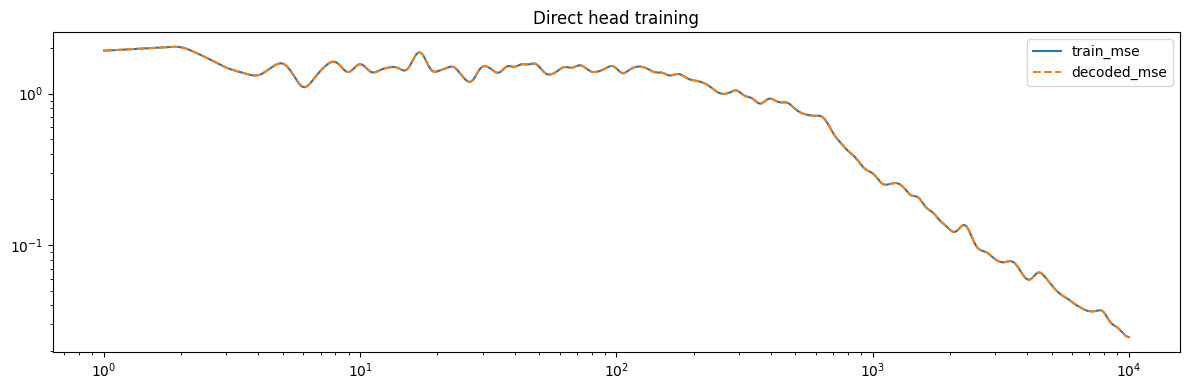

In [11]:
plot_direct(direct_metrics, cfg)

In [12]:
sef_metrics = run_sign_exp_frac(cfg)

100%|██████████| 10000/10000 [01:42<00:00, 97.95it/s]


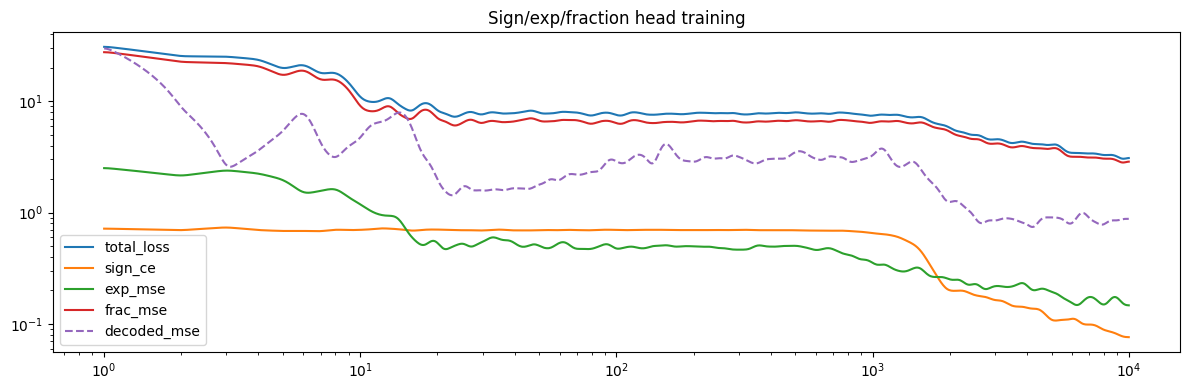

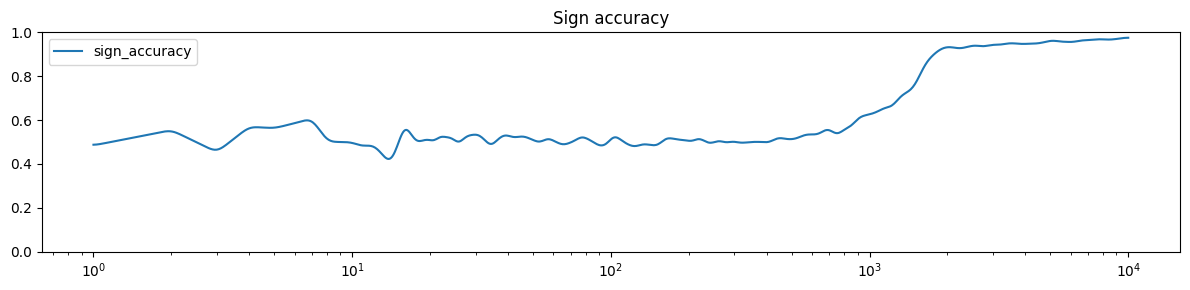

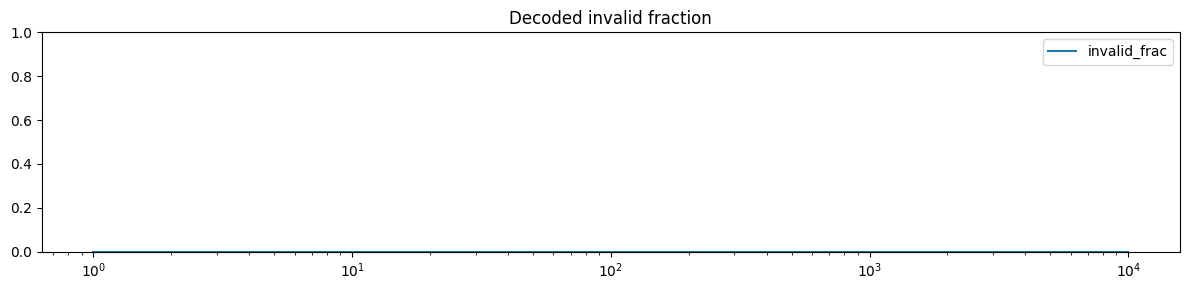

In [13]:
plot_sign_exp_frac(sef_metrics, cfg)

In [14]:
ieee_metrics = run_ieee(cfg)

  6%|▌         | 622/10000 [00:05<01:22, 114.27it/s]/tmp/ipykernel_12748/3709179939.py:29: RuntimeWarning: overflow encountered in square
  mse = float(np.mean((y_hat[mask] - y_true[mask]) ** 2))
100%|██████████| 10000/10000 [01:38<00:00, 101.48it/s]


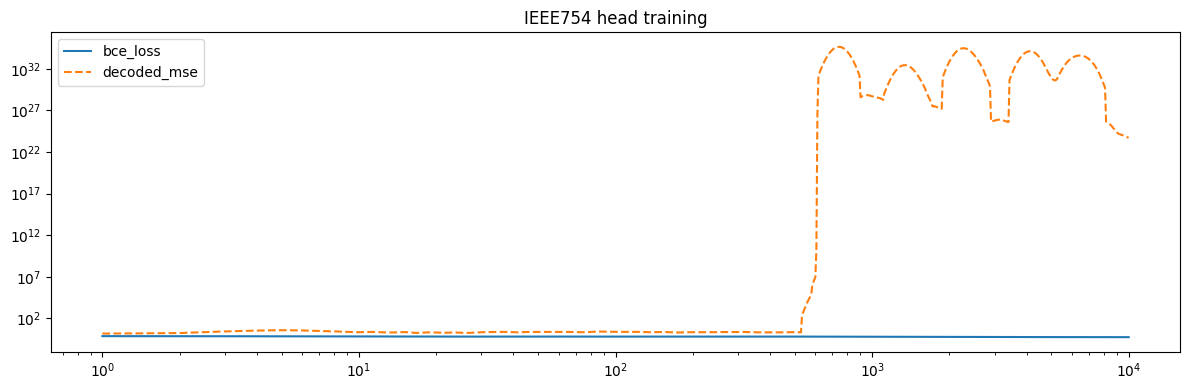

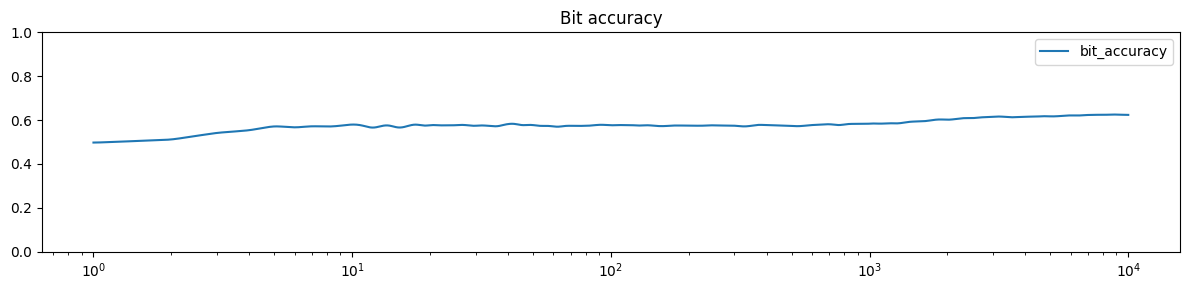

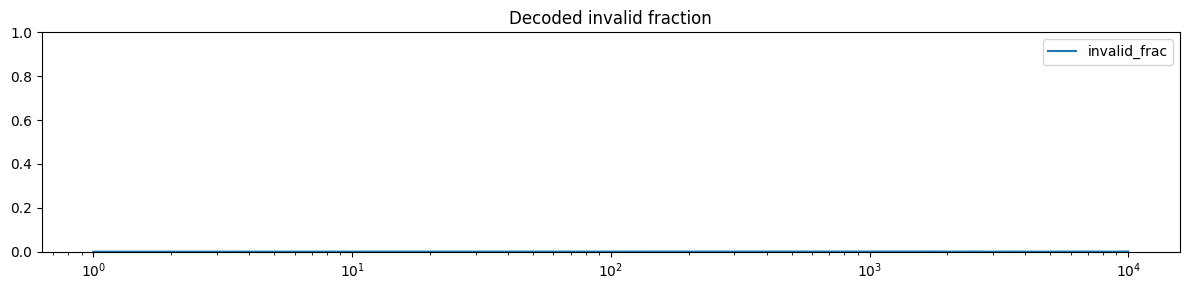

In [15]:
plot_ieee(ieee_metrics, cfg)